# RAPID-MFA 14: Trouble shooting: initial stock with a flow driven model

## Descriptions

This variant of the flow driven model allows to solve the _initial stocks problem_, which represents any stocks that are already existing in the system prior to the time series are accounted for, because the model assumes that the initial inflow starts building up the stock from zero. In this case, the time series begins in 1970; however, data indicates that accumulation has been ongoing since 1878. To address this, two datasets are integrated: one historic showing the flows between 1878 and 2005, and another from 1970 to 2021 to do so. 

### Exogenous variables
__Inflows:__ the inflows from 1878 to 2005 comes from _Gierlinger, S., & Krausmann, F. (2012). The physical economy of the United States of America: Extraction, trade, and consumption of materials from 1870 to 2005. Journal of Industrial Ecology, 16(3), 365-377_.

__Survival curve:__ mock values. Weibull distribution, chosen to exemplify that the model works even in a case in which survival in year 0 is not 100%, i.e. there is already some outflow (throughput) from each inflow in its year of occurance.

### Notes
1. This example requires two data sets, one showing the historic data before the target year (1970), and the data which we build our MFA from. 
2. This example uses Weibull survival curves, but they can be replaced with any other curves.

### Relations with other RAPID-MFA codes
- `RAPID-MFA-1: The flow driven model`: The modelling steps are following those in this notebook.
- `RAPID-MFA-15a: Troubleshooting the initial stock, stock driven model using a different survival curve for the zeroth cohort`: allows to solve the initial stock problem, but using a stock driven model instead.
- `RAPID-MFA 15b: Trouble shooting: initial stock with a stock driven model using leaching model`: is an alternative solution using the stock driven model to the same initial stock problem.
- `RAPID-MFA 15c: Trouble shooting: initial stock with a stock driven model`: is an alternative solution using the stock driven model to the same initial stock problem.


### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [1]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats

## 2. Define example input data

In [2]:
# %% 2. Define example input data
input_data = pd.Series([3616.6, 3646.4, 3664.9, 3696.5, 3725.9, 3756.9, 3796.2, 3831.3, 3854.1, 3870.3, 3902.9, 
                        3947.3, 3990.2, 4025.1, 4050.8, 4086, 4114.2, 4155.7, 4199.2, 4240, 4288.6, 4340.4, 4384.7, 4811.95, 
                        5698.9595, 5681.2625, 4707.6295, 5095.9345, 4775.2745, 7382.528, 5444.328, 4922.688, 5190.0315, 
                        5482.815, 4131.053, 4068.78, 3530.3315, 4487.776, 5490.0695, 5582.431, 7357.847, 7653.1625, 6694.6115, 
                        7277.4665, 7346.8265, 8697.1565, 8274.3305, 7612.059, 8573.134, 8892.0705, 9553.6945, 9436.8135, 
                        8469.71, 8573.831, 8612.117, 9279.937, 9853.25, 10049.05, 11041.8, 12152.25, 13675.75, 16812.95, 
                        16767.3, 18514.65, 15002.9, 21120, 19784.6, 8859.4, 10959.3, 12177.55, 12997.05, 14262.6, 18925.5, 
                        25660.8, 24864.4, 27925.7, 25924.6, 27816.1, 29404.7, 31013.45, 28466.1, 29534.7, 31534.75, 32430.45, 
                        38788.66435, 42168.35177, 41581.40087, 44139.03379, 48468.39413, 53754.8514, 55319.01862, 55623.93689, 
                        59991.76481, 58462.17136, 60432.07508, 64664.24864, 59597.03284, 49721.66962, 66996.73883, 47688.21159, 
                        55011.8449, 57959.01124, 53307.85549, 44414.37762, 46196.169, 45545.5886, 44744.09596, 45773.42893, 
                        44888.77484, 48006.02505, 46736.83916, 48416.68189, 45564.5079, 43030.0552, 38486.20835, 40024.90031, 
                        38596.18686, 37870.17762, 36957.39944, 36240.3304, 28135.42803, 29919.05566, 29329.73465, 25814.12385, 
                        25407.27876, 25674.31692, 26142.8053, 25357.6857],
                        name = "inflows",
                        index = [1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 
                                1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 
                                1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 
                                1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 
                                1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 
                                1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 
                                1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 
                                1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 
                                1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005]) 


# Parameters for the survival curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
shape = 4
location = 0
scale = 45

# create the survival curves
survival_curve = scipy.stats.weibull_min.sf(ages, c = shape, loc = location, scale = scale)

## 3. Run the flow-driven model

The steps from hereon are a repetition of notebook 1, but with different input data. If you want a more detailed account on how to do this, see notebook 1.

In [3]:
# %% 3. Run the flow-driven model
units = {'time_interval':   'year', 
         'flows':           'kg/year', 
         'stocks':          'kg'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1 # Interval between timeframes, usually 1, e.g. from 2005 to 2006 but can be different, e.g. 2005 to 2010. In which case time_interval = 5
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system = pd.DataFrame(index = timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['inflows'] = input_data

# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, we shift the survival curve and we fill the survival curve matrix with the shifted survival curve
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]

# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # scale the shifted survival curve with the inflow of the time-th year
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system['inflows'].loc[cohort]

mfa_system["stocks"] = cohorts_survival_matrix.sum(axis='columns')
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

## 4. Identify the initial stock issue

To identify the initial stocks before the year 1930, we can visualize the stocks by cohorts

Text(1971, 1811166.2395667695, '1970')

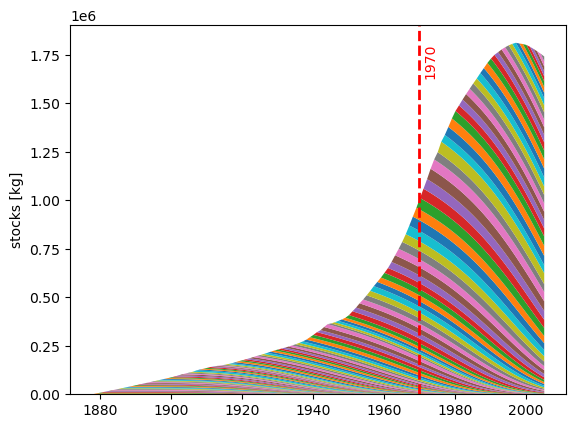

In [4]:
# %% 4. Identify the initial stock issue
# plot stocks by cohorts
ax = cohorts_survival_matrix.plot(kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]")
ax.axvline(x=1970, color='red', linestyle='--', linewidth=2)
ax.text(1970 + 1, ax.get_ylim()[1]*0.95, '1970', color='red', rotation=90, va='top')

By doing so we can identify how much stock there was already present in 1970. However, we can also see if the explicit inclusion of the years before 1970 are relevant.

In [5]:
print("In the year 1970, only",
    ((cohorts_survival_matrix.loc[1970, 1878] / mfa_system.loc[1970, "stocks"]) * 100).round(2),
    "% of the inflow from 1878 was still in stock.")

In the year 1970, only 0.0 % of the inflow from 1878 was still in stock.


Since the proportion of the stock before 1970 is so minimal, we can exclude it from our model. Now we have the initial stock for the year 1930.

<Axes: ylabel='stocks [kg]'>

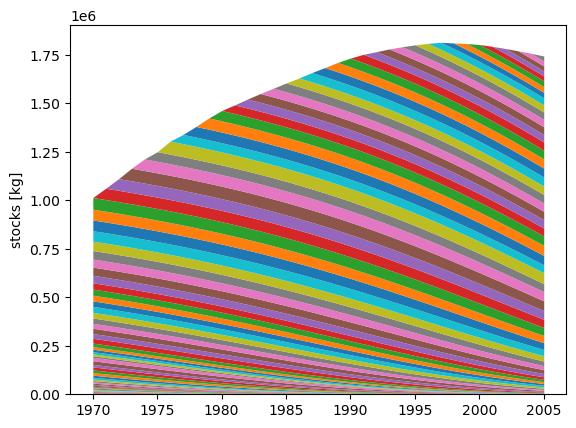

In [6]:
# plot stocks by cohorts starting from 1970
cohorts_survival_matrix.loc[1970:].plot(kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]")

## 5. Concluding remarks

The flows and stocks from 1970 look much more reasonable now. Interesting that in the early 1980s inflows for maintenance (outflows) overtook inflows for expansion (stock_changes).

The truncated 1870-1970 is called the _model spin-up_ or _buffer_ period. It's there to build up the stocks and flows, but excluded from analysis and discussion of the results.

The two MFA models can be joint into a single time series. Note that there might be a _sudden jolt_ in the transition year, see `RAPID-MFA-16: Sudden jumps` for how to solve this.